In [1]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_challenge_2.h5ad"
)

print(adata)

adata_hvg, hvg_genes,sig_genes = subset_to_hvg(
    adata,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt",
    include_signature_genes=True
)

print(adata_hvg.var_names)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 90815 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'
HVG requested: 10000
Signature genes requested: 820
Signature genes used: 481
Total genes used: 10481
Index(['MIR1302-2HG', 'AL627309.1', 'AL669831.2', 'AL645608.4', 'SAMD11',
       'PLEKHN1', 'HES4', 'AL645608.1', 'RNF223', 'SDF4',
       ...
       'LAMB3', 'LRG1', 'MB', 'NAPEPLD', 'NUDT7', 'PEX11A', 'RREB1', 'SLC2A4',
       'SOX13', 'VSTM2A'],
      dtype='object', name='gene', length=10481)


In [10]:
import joblib

joblib.dump(
    list(adata_hvg.var_names),
    "hvg_gene_order_no_whiten.joblib"
)

print("saved gene order:", len(adata_hvg.var_names))

saved gene order: 10481


In [3]:
from sklearn.decomposition import PCA
from scripts.pca import compute_pca_latent


adata_hvg, scaler = compute_pca_latent(adata_hvg, save_path='pca_512_no_whiten.joblib', d=512, whiten = False)

print(adata_hvg.obsm["X_pca"].shape)

save in pca_512_no_whiten.joblib
(90815, 512)


In [4]:
import sys
sys.path.append('../')
from scripts.pairing import assign_state_label, build_pairs_from_anndata
adata_hvg.obs["state"] = assign_state_label(
    adata_hvg.obs
)

pairs = build_pairs_from_anndata(
    adata_hvg,
        # verbose=True

)

print(len(pairs))

CEBPA+CEBPA 1624 all-pairs
CEBPA+CEBPA+CEBPB 28 all-pairs
CEBPA+CEBPA+NR3C1 28 all-pairs
CEBPA+CEBPA+POLR2D 28 all-pairs
CEBPA+CEBPA+STAT5B 56 all-pairs
CEBPA+CEBPB 2380 all-pairs
CEBPA+CEBPB+KIF11 28 all-pairs
CEBPA+CEBPB+NR3C1 28 all-pairs
CEBPA+CEBPB+STAT5B 28 all-pairs
CEBPA+CEBPD 3864 all-pairs
CEBPA+CREB1 7056 all-pairs
CEBPA+FOXO1 2912 all-pairs
CEBPA+KIF11 1176 all-pairs
CEBPA+KIF11+NR3C1 56 all-pairs
CEBPA+KIF11+STAT5B 28 all-pairs
CEBPA+MLXIPL 4704 all-pairs
CEBPA+NC 2044 all-pairs
CEBPA+NC detected as single-gene perturbation
CEBPA+NC 5329 random (NC fallback)
CEBPA+NC+NC 28 all-pairs
CEBPA+NC+NC detected as single-gene perturbation
CEBPA+NC+NC 4 random (NC fallback)
CEBPA+NC+STAT5B 28 all-pairs
CEBPA+NC+ZBED3 28 all-pairs
CEBPA+NR3C1 2072 all-pairs
CEBPA+NR3C1+NR3C1 28 all-pairs
CEBPA+NR3C1+POLR2D 56 all-pairs
CEBPA+NR3C1+SF3B1 28 all-pairs
CEBPA+NR3C1+STAT5B 56 all-pairs
CEBPA+NR3C1+ZBED3 28 all-pairs
CEBPA+POLR2D 1652 all-pairs
CEBPA+PPARG2 2352 all-pairs
CEBPA+SF3B1 2296

In [5]:
from scripts.flow_dataset import FlowPairDataset
import torch
dataset = FlowPairDataset(pairs)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=512,
    shuffle=True
)

In [6]:
from scripts.flow_model import FlowMLP
latent_dim = pairs[0]["z0"].shape[0]

cond_dim = pairs[0]["cond"].shape[0]

model = FlowMLP(

    latent_dim,

    cond_dim
)

In [19]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scripts.flow_loss import (
    flow_matching_loss_pairs,
    flow_matching_loss_gaussian
)


device = "mps"

model.to(device)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3
)


# ------------------
# config
# ------------------

max_epochs = 500

patience = 15          # early stop patience

min_delta = 1e-4       # minimum improvement

save_path = Path("model/best_flow_no_whiten.pt")

loss_csv_path = Path("model/loss_curve.csv")

plot_path = Path("model/loss_curve.png")

save_path.parent.mkdir(parents=True, exist_ok=True)


# ------------------
# tracking
# ------------------

best_loss = float("inf")

epochs_no_improve = 0

all_epoch_losses = []


# ------------------
# training loop
# ------------------

for epoch in range(max_epochs):

    losses = []

    model.train()

    for z0, z1, cond in loader:

        z0 = z0.to(device)

        z1 = z1.to(device)

        cond = cond.to(device)


        loss = flow_matching_loss_pairs(

            model,

            z0,

            z1,

            cond

        )


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        losses.append(

            loss.item()

        )


    epoch_loss = float(np.mean(losses))

    all_epoch_losses.append(epoch_loss)


    # ------------------
    # save best model
    # ------------------

    if epoch_loss < best_loss - min_delta:

        best_loss = epoch_loss

        epochs_no_improve = 0


        torch.save(

            {

                "model_state_dict": model.state_dict(),

                "optimizer_state_dict": optimizer.state_dict(),

                "epoch": epoch,

                "loss": best_loss

            },

            save_path

        )


        print(

            f"[SAVE] epoch {epoch}  loss {best_loss:.6f}"

        )


    else:

        epochs_no_improve += 1


    # ------------------
    # print progress
    # ------------------

    if epoch % 20 == 0:

        print(

            f"epoch {epoch}  loss {epoch_loss:.6f}"

        )


    # ------------------
    # early stopping
    # ------------------

    if epochs_no_improve >= patience:

        print(

            f"\nEARLY STOP at epoch {epoch}"

        )

        break


# ------------------
# save loss curve
# ------------------

loss_df = pd.DataFrame(

    {

        "epoch": np.arange(len(all_epoch_losses)),

        "loss": all_epoch_losses

    }

)

loss_df.to_csv(

    loss_csv_path,

    index=False

)


# ------------------
# plot
# ------------------

plt.figure()

plt.plot(all_epoch_losses)

plt.xlabel("epoch")

plt.ylabel("loss")

plt.title("Flow Matching Training Loss")

plt.savefig(plot_path)

plt.close()


print("\nBest loss:", best_loss)

print("model saved to:", save_path)

print("loss curve saved to:", loss_csv_path)

print("plot saved to:", plot_path)

[SAVE] epoch 0  loss 2.948715
epoch 0  loss 2.948715
[SAVE] epoch 1  loss 2.882704
[SAVE] epoch 2  loss 2.879597
[SAVE] epoch 3  loss 2.874507
[SAVE] epoch 4  loss 2.873605
[SAVE] epoch 5  loss 2.869810
[SAVE] epoch 6  loss 2.863860
[SAVE] epoch 7  loss 2.859110
[SAVE] epoch 8  loss 2.851513
[SAVE] epoch 9  loss 2.848404
[SAVE] epoch 10  loss 2.845892
[SAVE] epoch 12  loss 2.843364
[SAVE] epoch 13  loss 2.836486
[SAVE] epoch 14  loss 2.830421
[SAVE] epoch 16  loss 2.825051
[SAVE] epoch 17  loss 2.822246
[SAVE] epoch 18  loss 2.819375
[SAVE] epoch 19  loss 2.813308
epoch 20  loss 2.814534
[SAVE] epoch 21  loss 2.807545
[SAVE] epoch 22  loss 2.800981
[SAVE] epoch 24  loss 2.799219
[SAVE] epoch 25  loss 2.796003
[SAVE] epoch 26  loss 2.790179
[SAVE] epoch 27  loss 2.790043
[SAVE] epoch 28  loss 2.788745
[SAVE] epoch 29  loss 2.785525
[SAVE] epoch 30  loss 2.780161
[SAVE] epoch 33  loss 2.774993
[SAVE] epoch 34  loss 2.774429
[SAVE] epoch 35  loss 2.774235
[SAVE] epoch 36  loss 2.770238
[S

In [20]:
import scanpy as sc
import torch
import joblib
import numpy as np

control_path = "../../data/preprocessed/control_cells/NC_NC_control_cells.h5ad"

adata_ctrl_NCNC = sc.read_h5ad(control_path)


import joblib

gene_order = joblib.load(
    "hvg_gene_order_no_whiten.joblib"
)

adata_ctrl_hvg = adata_ctrl_NCNC[:, gene_order].copy()


print(adata_ctrl_hvg)
pca = joblib.load("pca_512_no_whiten.joblib")

X_ctrl = adata_ctrl_hvg.X

if not isinstance(X_ctrl, np.ndarray):
    X_ctrl = X_ctrl.toarray()

z_NCNC = pca.transform(X_ctrl)

print(z_NCNC.shape)

AnnData object with n_obs × n_vars = 100 × 10481
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo', 'state'
    layers: 'counts'
(100, 512)


In [21]:
import scanpy as sc
import torch
import joblib
import numpy as np

control_path = "../../data/preprocessed/control_cells/NC_control_cells.h5ad"

adata_ctrl_NC = sc.read_h5ad(control_path)

import joblib

gene_order = joblib.load(
    "hvg_gene_order_no_whiten.joblib"
)

adata_ctrl_hvg = adata_ctrl_NC[:, gene_order].copy()

print(adata_ctrl_hvg)


print(adata_ctrl_hvg)
pca = joblib.load("pca_512_no_whiten.joblib")

X_ctrl = adata_ctrl_hvg.X

if not isinstance(X_ctrl, np.ndarray):
    X_ctrl = X_ctrl.toarray()

z_NC = pca.transform(X_ctrl)

print(z_NC.shape)

AnnData object with n_obs × n_vars = 100 × 10481
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo', 'state'
    layers: 'counts'
AnnData object with n_obs × n_vars = 100 × 10481
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo', 'state'
    layers: 'counts'
(100, 512)


In [22]:
from pathlib import Path

pert_list = Path(
    "../../data/predict_perturbations_2.txt"
).read_text().splitlines()

print(len(pert_list))
print(pert_list[:10])

62
['CREB1', 'MLXIPL', 'SREBF1', 'CEBPD', 'PPARG2', 'FOXO1', 'PPARG', 'CREB1+MLXIPL', 'CREB1+PPARG2', 'STAT5B+TCF7L2']


In [23]:
from scripts.flow_model import FlowMLP

device = "mps"

# 1️⃣ 建立 model
model = FlowMLP(

    dim=512,

    cond_dim=19,

    hidden=1024

)

model.to(device)

# 2️⃣ 讀取 checkpoint
checkpoint = torch.load(

    "model/best_flow_no_whiten.pt",

    map_location=device

)

# 3️⃣ 載入權重
model.load_state_dict(

    checkpoint["model_state_dict"]

)

model.eval()

print(

    "loaded epoch:",

    checkpoint["epoch"]

)

print(

    "best loss:",

    checkpoint["loss"]

)

loaded epoch: 339
best loss: 2.580163900318732


In [24]:
from scripts.flow_pred import sample_all_perts


latent_all, pert_labels = sample_all_perts(

    model,

    pert_list,

    z_NC=z_NC,

    z_NCNC=z_NCNC,

    n_steps=1000
)
gene_pred = pca.inverse_transform(

    latent_all

)
gene_pred = np.clip(gene_pred,0,None)

CREB1                source: NC (100, 512)
MLXIPL               source: NC (100, 512)
SREBF1               source: NC (100, 512)
CEBPD                source: NC (100, 512)
PPARG2               source: NC (100, 512)
FOXO1                source: NC (100, 512)
PPARG                source: NC (100, 512)
CREB1+MLXIPL         source: NC+NC (100, 512)
CREB1+PPARG2         source: NC+NC (100, 512)
STAT5B+TCF7L2        source: NC+NC (100, 512)
MLXIPL+STAT5B        source: NC+NC (100, 512)
CREB1+NC             source: NC+NC (100, 512)
CEBPD+PPARG2         source: NC+NC (100, 512)
FOXO1+NC             source: NC+NC (100, 512)
SREBF1+ZBED3         source: NC+NC (100, 512)
PPARG2+STAT5A        source: NC+NC (100, 512)
CREB1+FOXO1          source: NC+NC (100, 512)
NC+PPARG             source: NC+NC (100, 512)
CEBPD+FOXO1          source: NC+NC (100, 512)
PPARG+PPARG2         source: NC+NC (100, 512)
CREB1+STAT5B         source: NC+NC (100, 512)
KLF15+PPARG2         source: NC+NC (100, 512)
PPARG+SRE

In [25]:
from scripts.scoring import reconstruct_full_expression_with_control
X_ctrl_NC = adata_ctrl_NC.X
X_ctrl_NCNC = adata_ctrl_NCNC.X


if not isinstance(X_ctrl_NC, np.ndarray):
    X_ctrl_NC = X_ctrl_NC.toarray()

if not isinstance(X_ctrl_NCNC, np.ndarray):
    X_ctrl_NCNC = X_ctrl_NCNC.toarray()


# 取 100 cells

X_ctrl_NC = X_ctrl_NC[:100]

X_ctrl_NCNC = X_ctrl_NCNC[:100]


X_pred_full = reconstruct_full_expression_with_control(

    adata_full = adata,

    adata_hvg  = adata_ctrl_hvg,

    X_hvg_rec  = gene_pred,

    pert_list = pert_list,

    X_ctrl_NC = X_ctrl_NC,

    X_ctrl_NCNC = X_ctrl_NCNC

)

In [26]:
from scripts.save_predict import save_prediction_h5ad
prediction_h5ad_file_path = "prediction.h5ad"
adata_pred = save_prediction_h5ad(

    X_pred_full = X_pred_full,

    adata_full = adata,
    latent_all = latent_all,   # PCA 512 維

    predict_perturbations = pert_list,

    genes_to_predict_path = "../../data/predict_genes_2.txt",

    prediction_h5ad_file_path = prediction_h5ad_file_path,

)

genes_to_predict: 36601


/opt/anaconda3/envs/X-Cells/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


latent stored in .obsm['X_pca']: (6200, 512)
Saved prediction: prediction.h5ad


# Predict

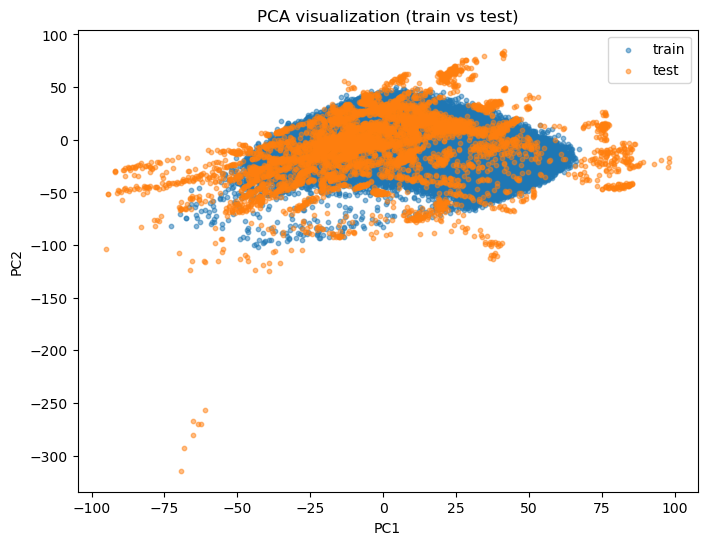

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# 取出 PCA features
X_train_pca512 = adata_hvg.obsm["X_pca"]
X_test_pca512  = adata_pred.obsm["X_pca"]

# 合併
X_all = np.vstack([X_train_pca512, X_test_pca512])

# 建立來源標籤
labels_source = (
    ["train"] * X_train_pca512.shape[0] +
    ["test"]  * X_test_pca512.shape[0]
)

labels_source = np.array(labels_source)

# 再做 PCA -> 2D 用於視覺化
pca_2d = PCA(n_components=2, random_state=42)

X_2d = pca_2d.fit_transform(X_all)

# 轉 dataframe
df_plot = pd.DataFrame({
    "PC1": X_2d[:,0],
    "PC2": X_2d[:,1],
    "dataset": labels_source
})

# 畫圖
plt.figure(figsize=(8,6))

for label in df_plot["dataset"].unique():

    subset = df_plot[df_plot["dataset"] == label]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.5,
        s=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA visualization (train vs test)")

plt.legend()

plt.show()